In [1]:

import numpy as np
import astropy.units as u
from datetime import datetime
today = int(datetime.today().strftime('%Y%m%d'))
from importlib import reload
from astropy.io import fits

import matplotlib.pyplot as plt
from matplotlib.patches import Circle

from scoob_llowfsc.math_module import xp, xcipy, ensure_np_array
from scoob_llowfsc.imshows import imshow1, imshow2, imshow3
from scoob_llowfsc import utils
from scoob_llowfsc import llowfsc_sim as llowfsc
import scoob_llowfsc.scoob_model as scoobm
import scoob_llowfsc.detector as detector

wfe_data = utils.load_pickle('sim-data/example_wfe_data.pkl')
iefc_data = utils.load_pickle('sim-data/example_iefc_data.pkl')
dh_command = iefc_data['commands'][-1]

reload(detector)
CAMLO = detector.DETECTOR(exp_time=0.001, blacklevel=100, read_noise=2, gain=4)

nominal_flux = 10e8 * u.ph/u.s/u.m**2

In [34]:
iefc_data.keys()

dict_keys(['images', 'contrast', 'commands', 'del_commands', 'pixelscale', 'control_mask', 'probes'])

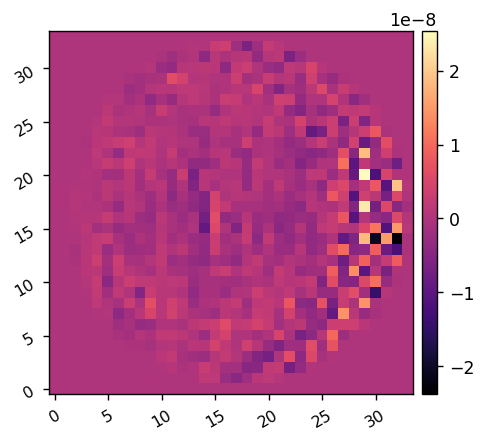

In [44]:
imshow1(dh_command)

Oversampling > 2x suggested for reliable results in Fresnel propagation.


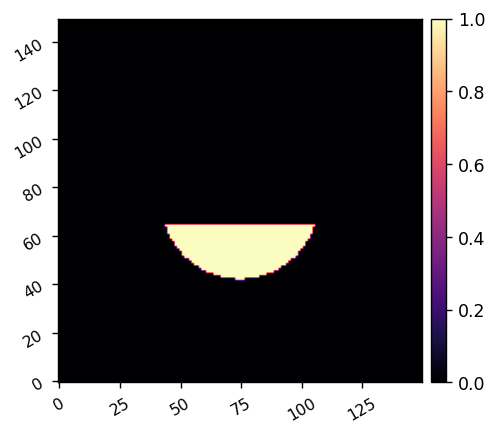

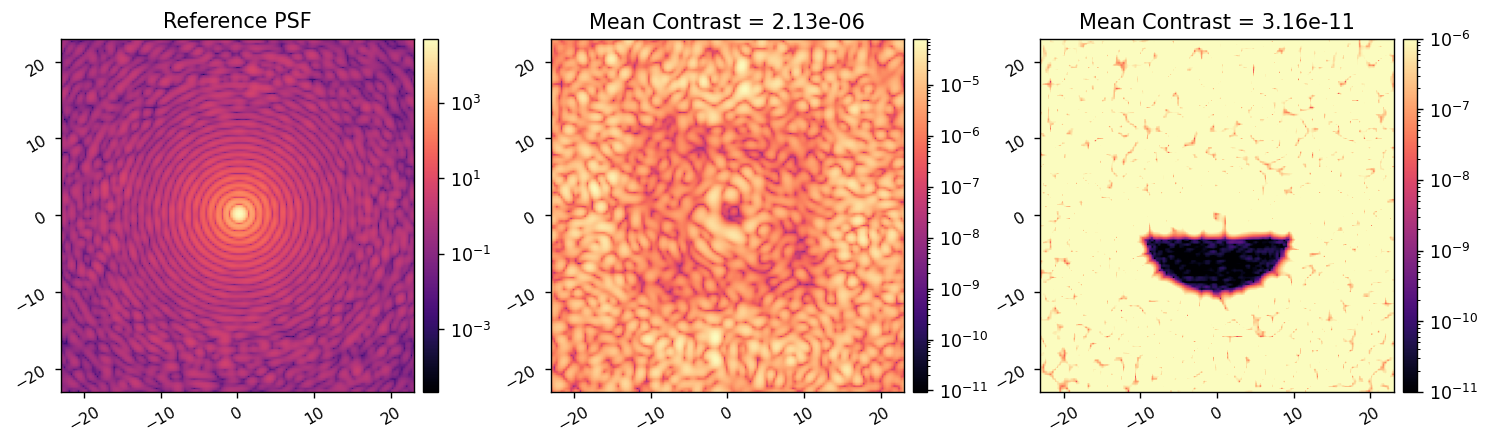

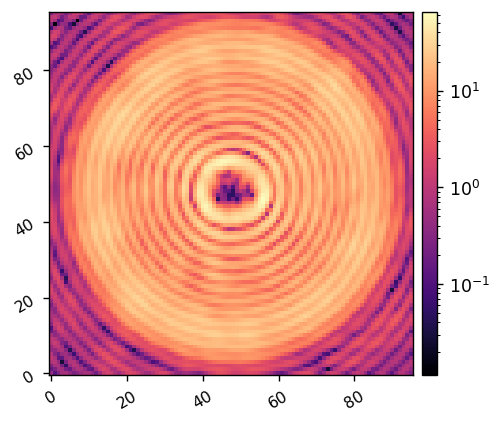

In [70]:
reload(scoobm)
reload(utils)

M = scoobm.single(
    dm_ref=wfe_data['DM_FLAT'],
    # entrance_flux=nominal_flux, 
)
M.reset_dm()
M.PREFPM_AMP = wfe_data['PREFPM_AMP']
M.PREFPM_OPD = wfe_data['PREFPM_OPD']

M.POSTFPM_AMP = wfe_data['POSTFPM_AMP']
M.POSTFPM_OPD = wfe_data['POSTFPM_OPD']

M.RLS_AMP = wfe_data['RLS_AMP']
M.RLS_OPD = wfe_data['RLS_OPD']

# M.CAMLO = CAMLO
# M.NCAMLO = 100

iwa = 3
owa = 10
dark_hole_mask = utils.create_annular_focal_plane_mask(
    M.ncamsci, 
    M.camsci_pxscl_lamD, 
    iwa, 
    owa,  
    edge=iwa,
    rotation=90,
)
imshow1(dark_hole_mask)

M.use_vortex = 0
ref_psf = M.snap_camsci()
M.Imax_ref = xp.max(ref_psf)

M.use_vortex = 1
camsci_im_ref = M.snap_camsci()
contrast_ref = xp.mean(camsci_im_ref[dark_hole_mask])

M.add_dm(dh_command, 3)
camsci_im_dh0 = M.snap_camsci()
contrast_dh0 = xp.mean(camsci_im_dh0[dark_hole_mask])
M.add_dm(-dh_command, 3)

imshow3(
    ref_psf, camsci_im_ref, camsci_im_dh0,
    'Reference PSF', f'Mean Contrast = {contrast_ref:.2e}', f'Mean Contrast = {contrast_dh0:.2e}', 
    pxscl=M.camsci_pxscl_lamDc,
    lognorm=1, 
    vmin3=1e-11, vmax3=1e-6,
)

M.llowfsc_defocus = 4.75*u.mm
camlo_im_ref = M.snap_camlo()
imshow1(camlo_im_ref, lognorm=1)

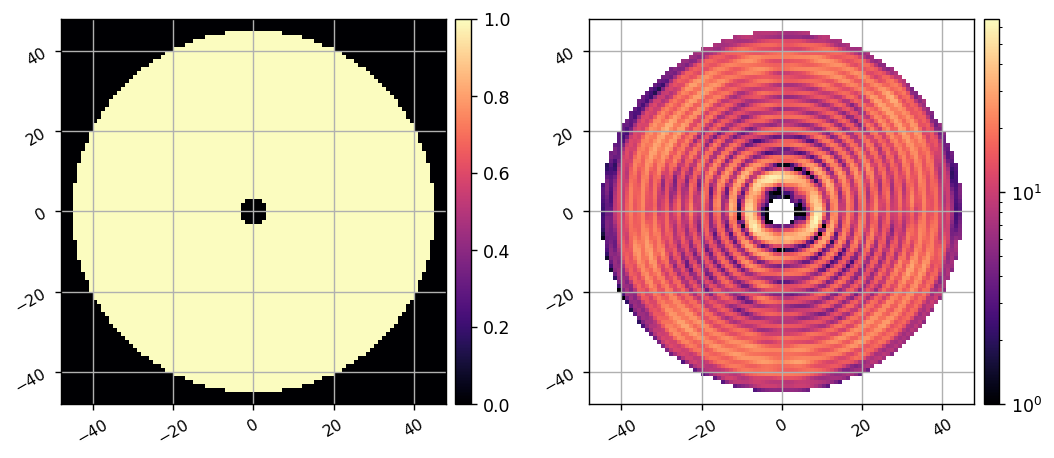

In [4]:
reload(llowfsc)
irad = 3
orad = 45
llowfsc_mask = utils.create_annular_focal_plane_mask(M.ncamlo, 1, irad, orad, edge=None, )
imshow2(llowfsc_mask, camlo_im_ref * llowfsc_mask, grid=True, pxscl=1, lognorm2=True, vmin2=10e-1)

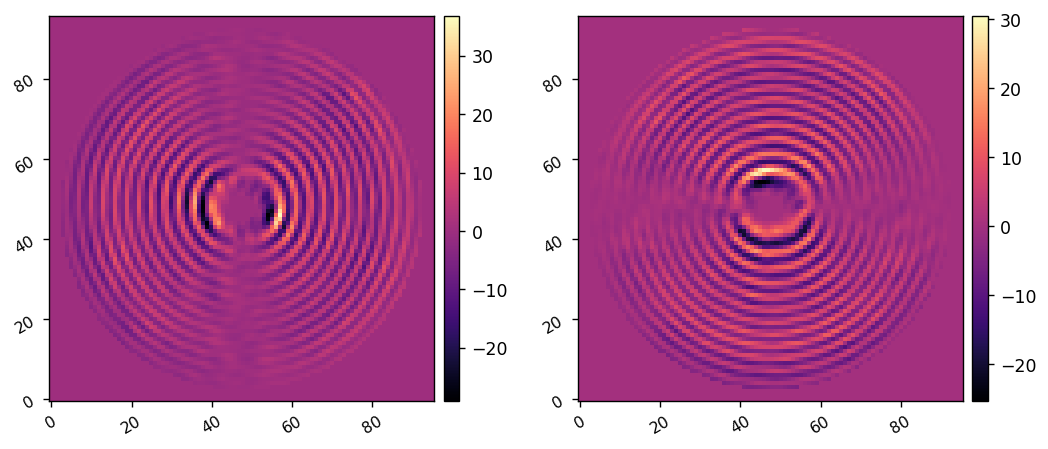

array([[[ 0., -0., -0., ...,  0.,  0.,  0.],
        [-0., -0.,  0., ...,  0.,  0.,  0.],
        [-0., -0.,  0., ..., -0.,  0.,  0.],
        ...,
        [ 0.,  0., -0., ...,  0., -0.,  0.],
        [-0.,  0.,  0., ..., -0., -0.,  0.],
        [-0., -0.,  0., ..., -0.,  0.,  0.]],

       [[ 0., -0., -0., ..., -0., -0., -0.],
        [-0., -0., -0., ...,  0., -0., -0.],
        [-0., -0.,  0., ...,  0.,  0., -0.],
        ...,
        [ 0., -0., -0., ...,  0., -0., -0.],
        [ 0.,  0., -0., ..., -0., -0., -0.],
        [ 0.,  0.,  0., ...,  0.,  0.,  0.]]])

In [18]:
reload(llowfsc)
llowfsc.make_shear_chops(
    camlo_im_ref, 
    llowfsc_mask,
    shear_pix=-1, 
    # central_diff=1,
    order=3,
    plot=1,
)

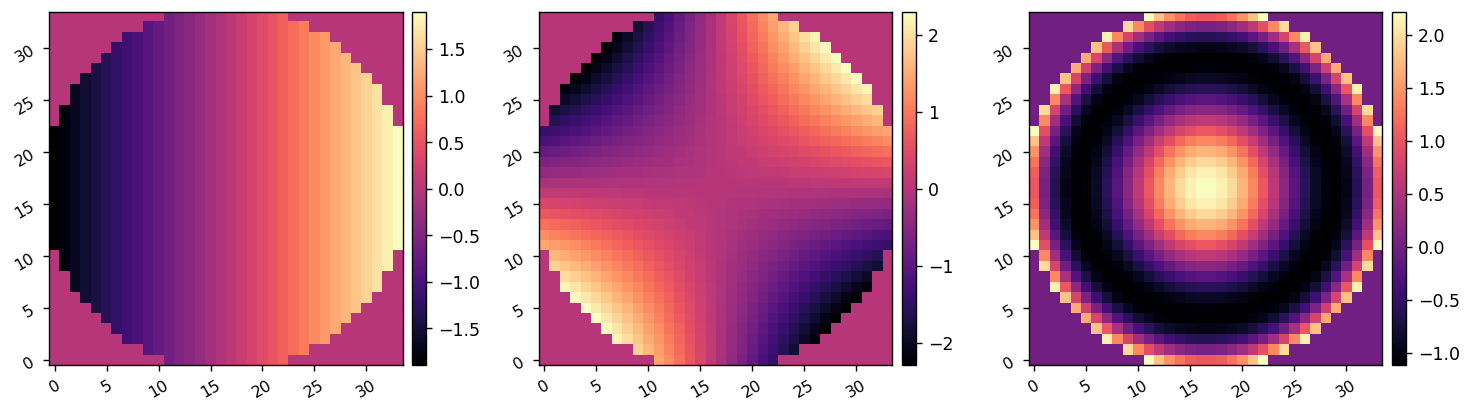

In [20]:
reload(utils)
zernike_modes = utils.create_zernike_modes(M.dm_mask, nmodes=10, remove_modes=1)
zer_modal_matrix = zernike_modes[:, M.dm_mask]
imshow3(zernike_modes[0], zernike_modes[3], zernike_modes[-1])

In [15]:
zernike_modes.shape

(10, 34, 34)

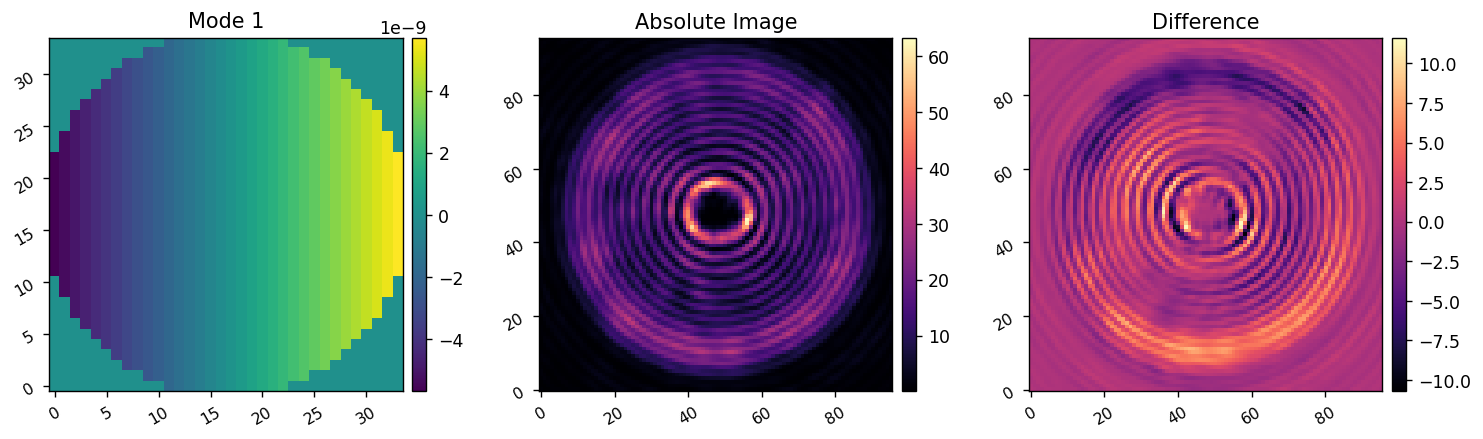

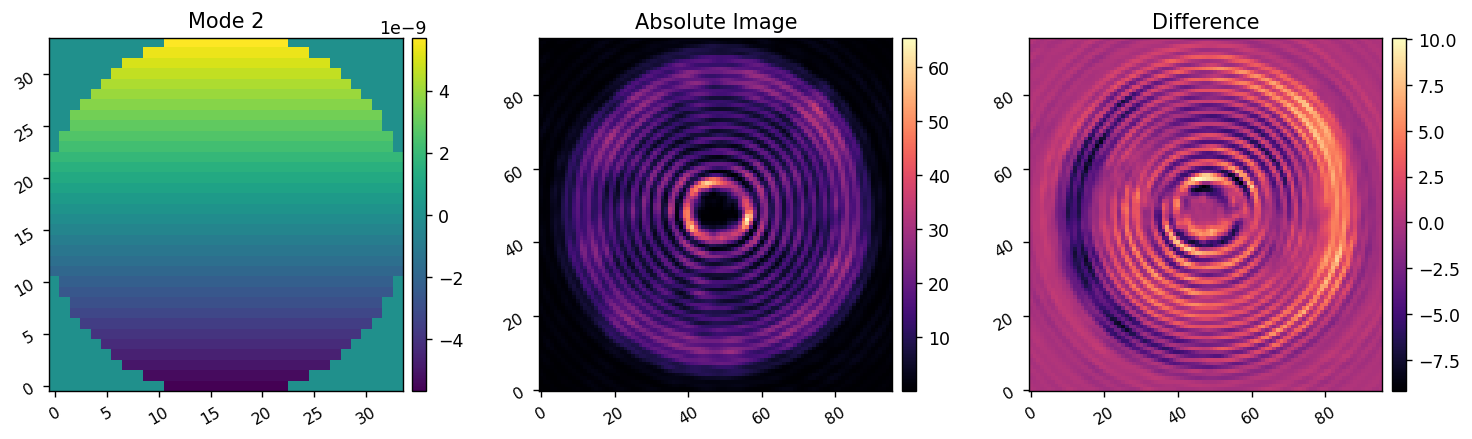

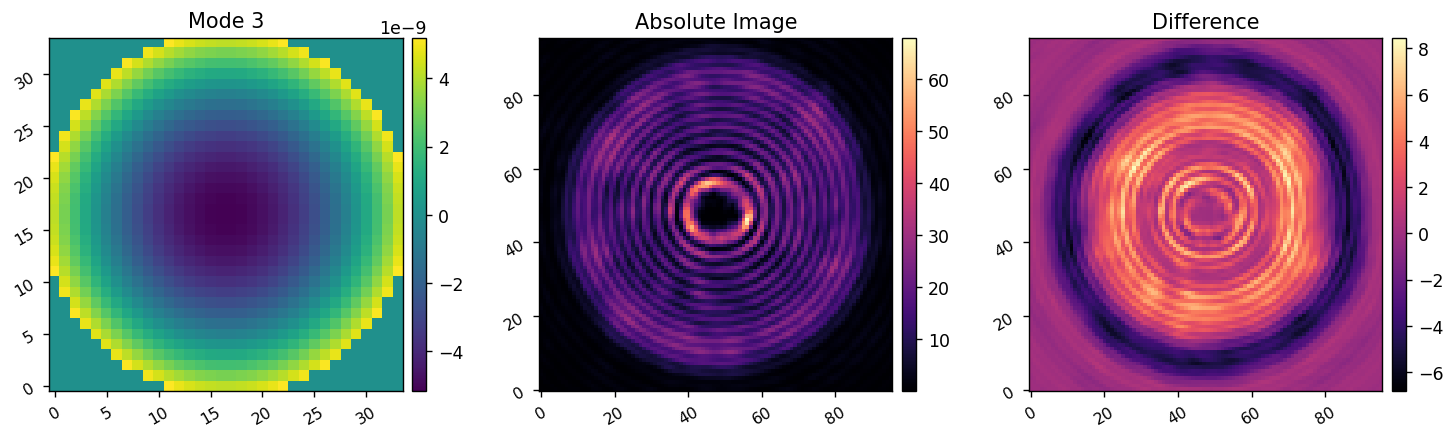

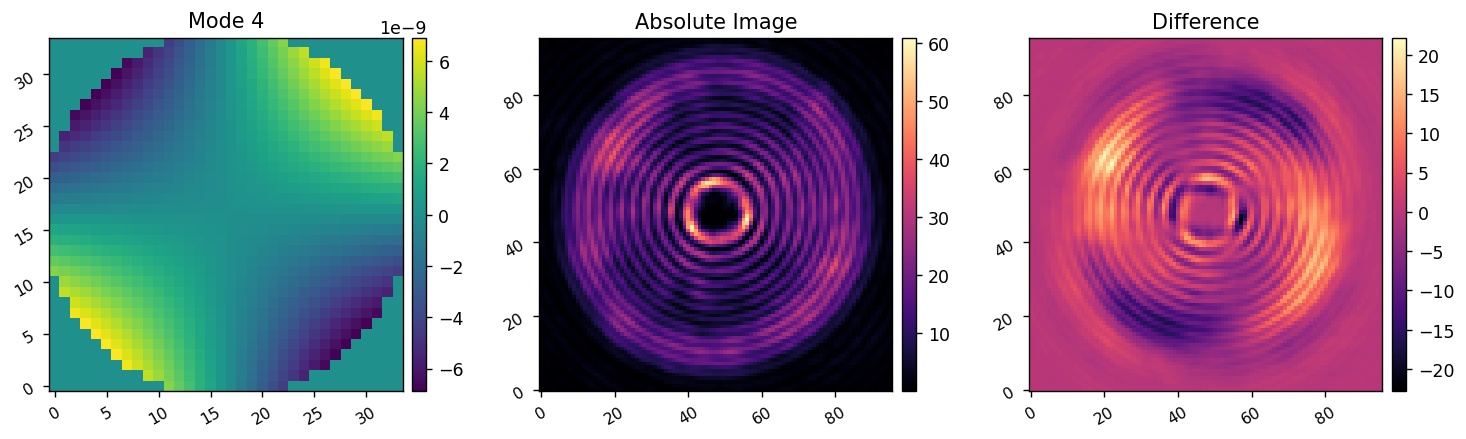

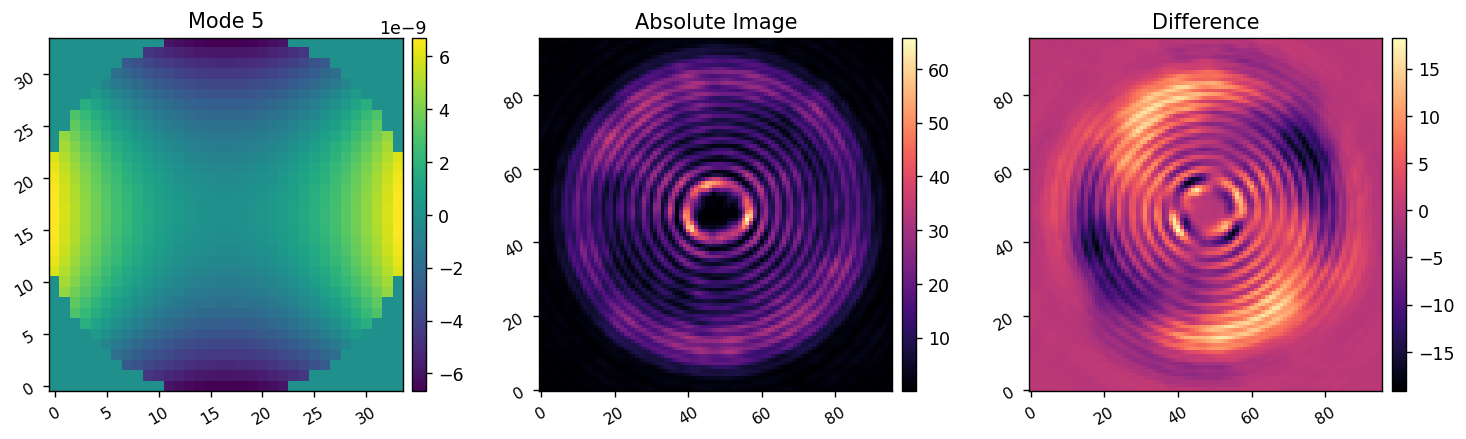

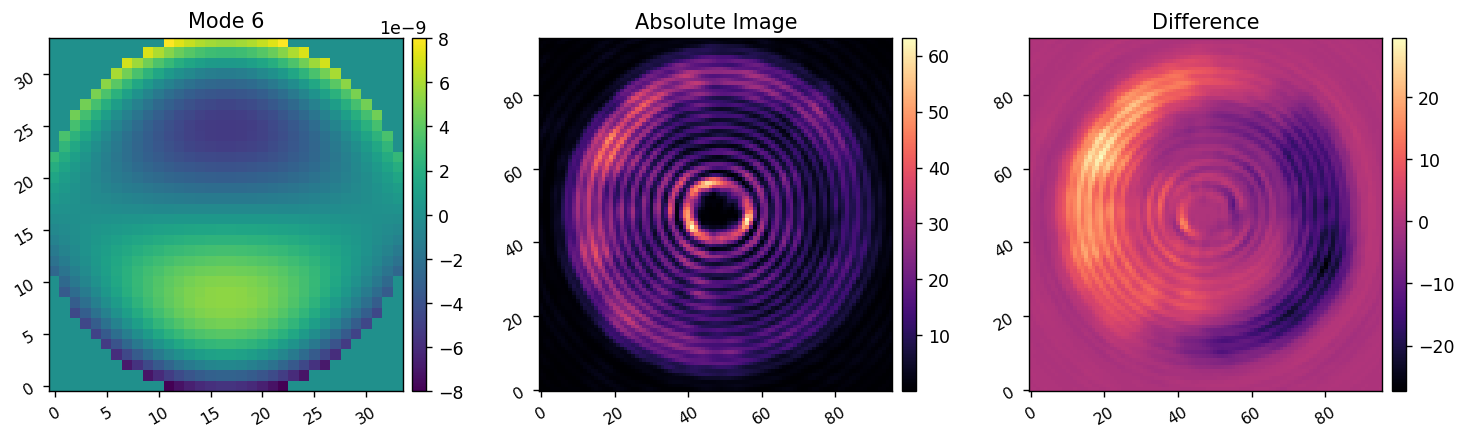

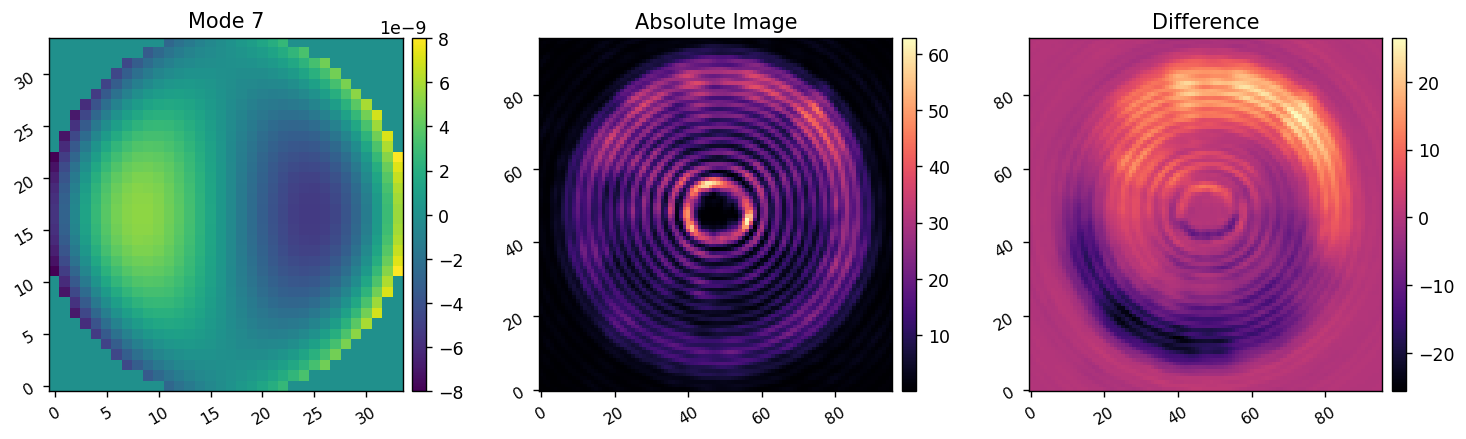

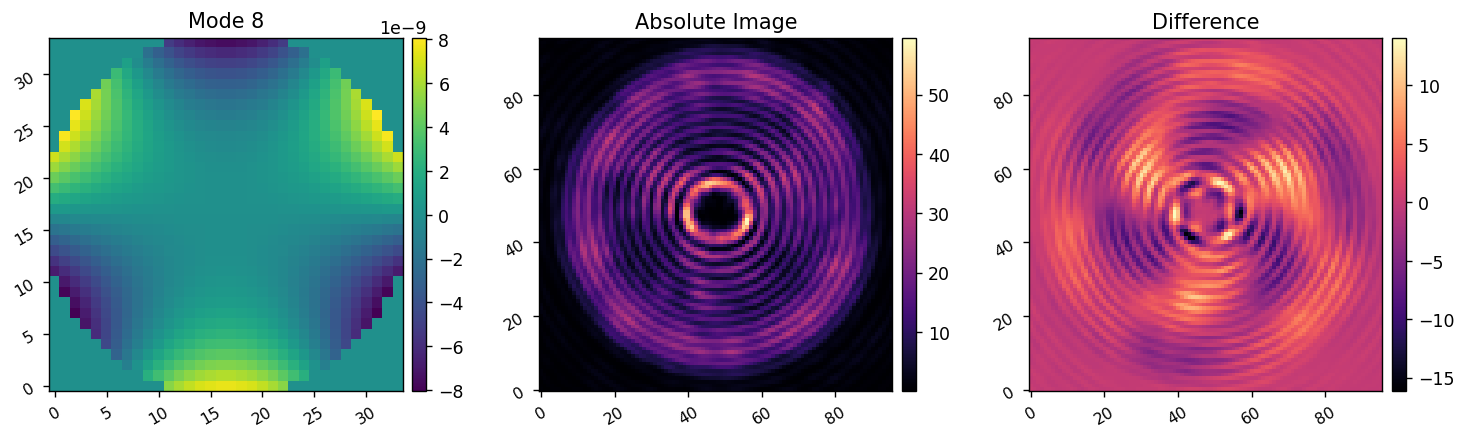

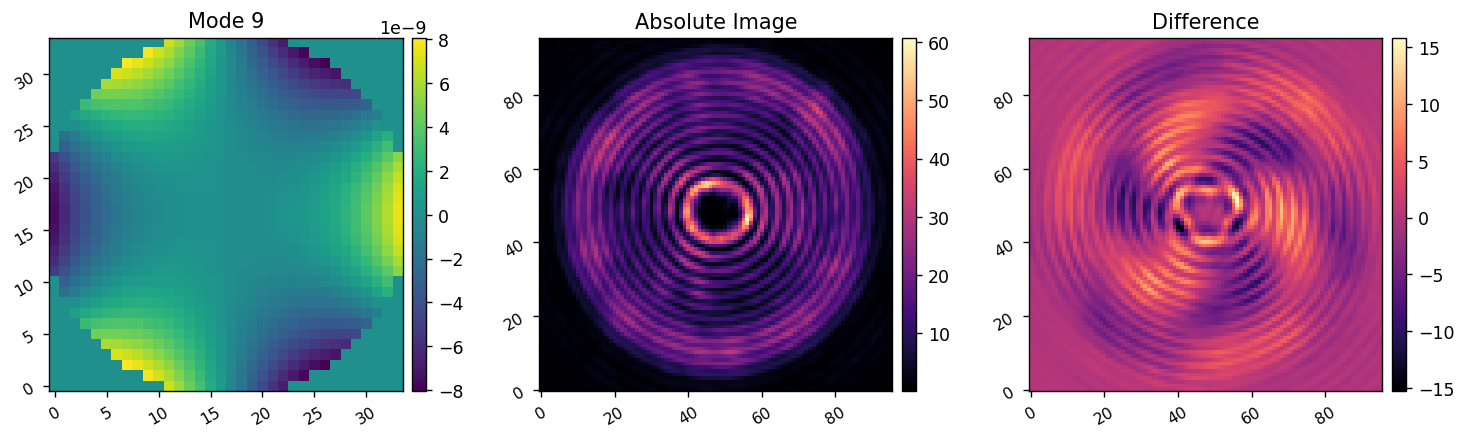

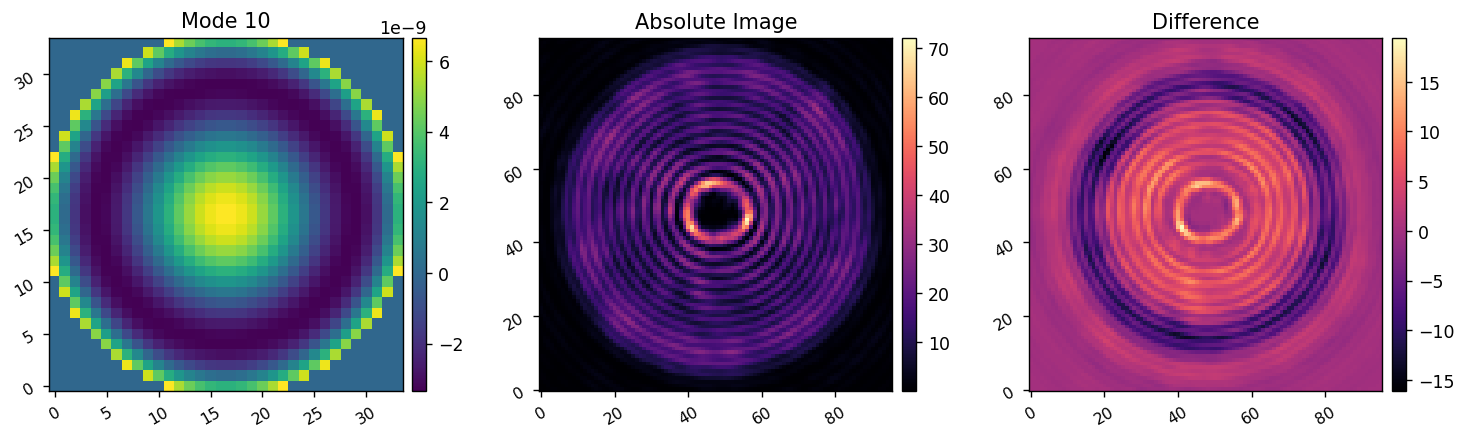

In [21]:
reload(llowfsc)
M.reset_dm()

M.setattr('use_vortex', True)
z_rm, z_response_cube = llowfsc.calibrate_without_fsm(
    M, 
    zernike_modes, 
    llowfsc_mask, 
    amps=3e-9, 
    plot=True,
)

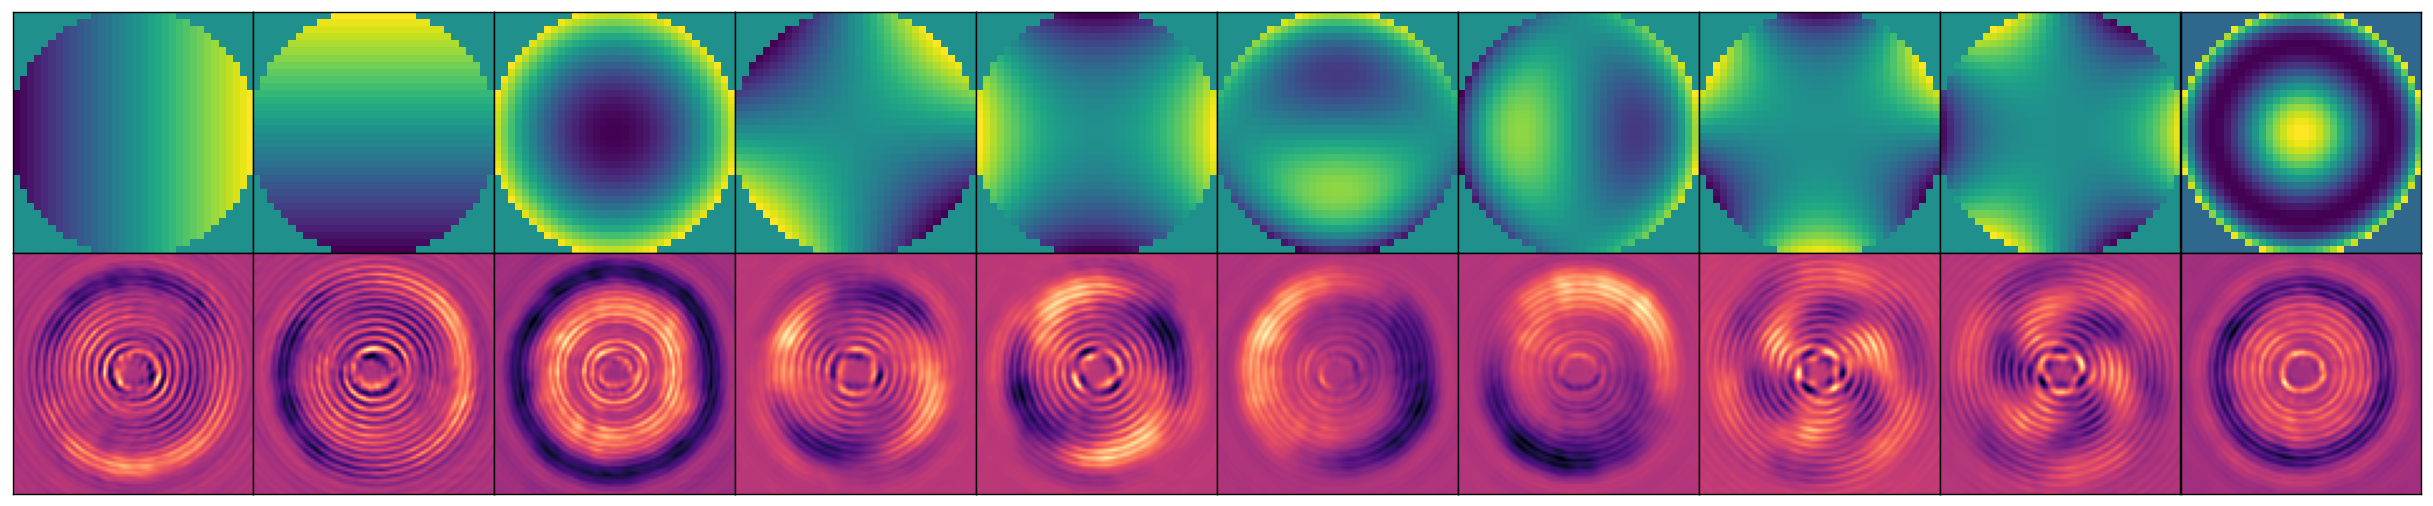

In [47]:
reload(llowfsc)
llowfsc.plot_responses(zernike_modes, z_response_cube)

In [48]:
control_matrix = utils.TikhonovInverse(z_rm, 0)

3.4887333561396425


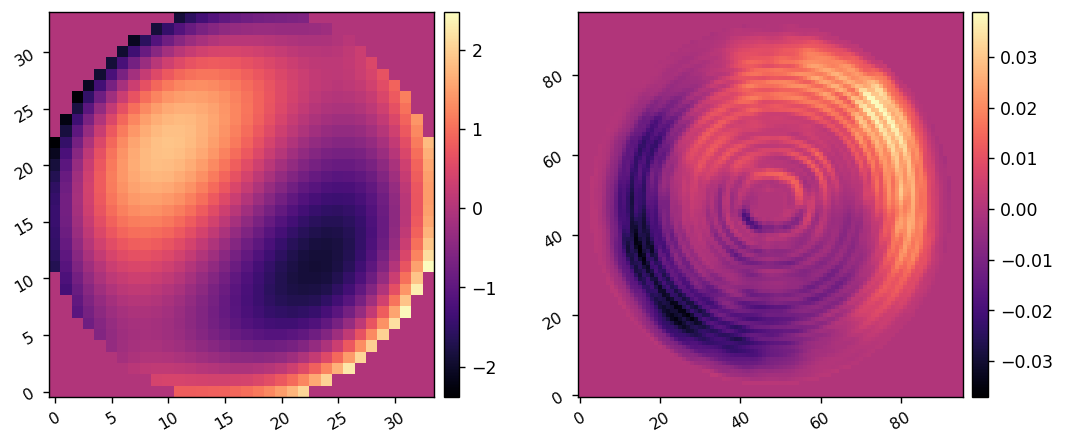

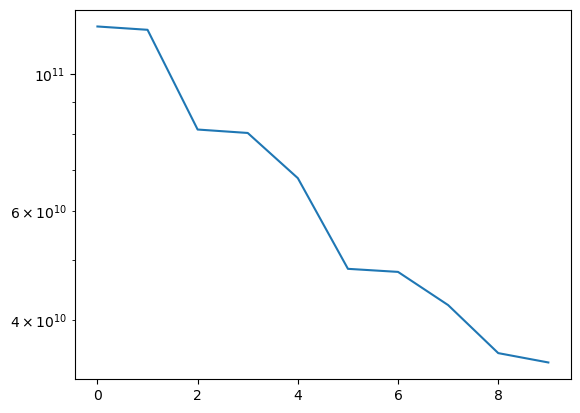

In [49]:

U, s, Vt = xp.linalg.svd(z_rm, full_matrices=False)
svd_dm_modes = Vt.dot(zer_modal_matrix)
print(s.max()/s.min())

i = 1
svd_dm_mode = xp.zeros_like(M.dm_total)
svd_dm_mode[M.dm_mask] = svd_dm_modes[i]
wfs_mode = xp.zeros_like(camlo_im_ref)
wfs_mode[llowfsc_mask] = U[:, i]
imshow2(svd_dm_mode, wfs_mode)
plt.semilogy(ensure_np_array(s))


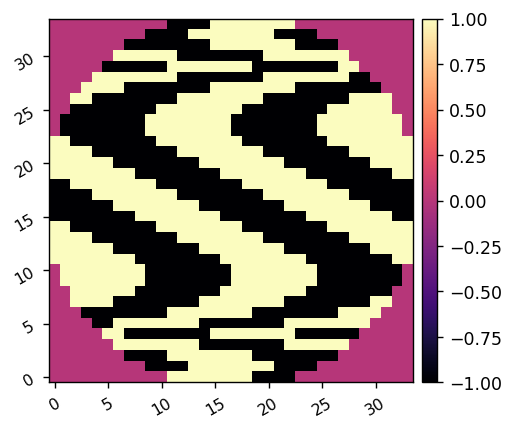

In [50]:
hadamard_modes = utils.create_hadamard_modes(M.dm_mask)
had_modal_matrix = hadamard_modes[:, M.dm_mask]

imshow1(hadamard_modes[8])

In [51]:
reload(llowfsc)
M.reset_dm()
M.setattr('use_vortex', True)

h_rm, h_response_cube = llowfsc.calibrate_without_fsm(
    M, 
    hadamard_modes, 
    llowfsc_mask, 
    amps=3e-9, 
    # plot=True,
)


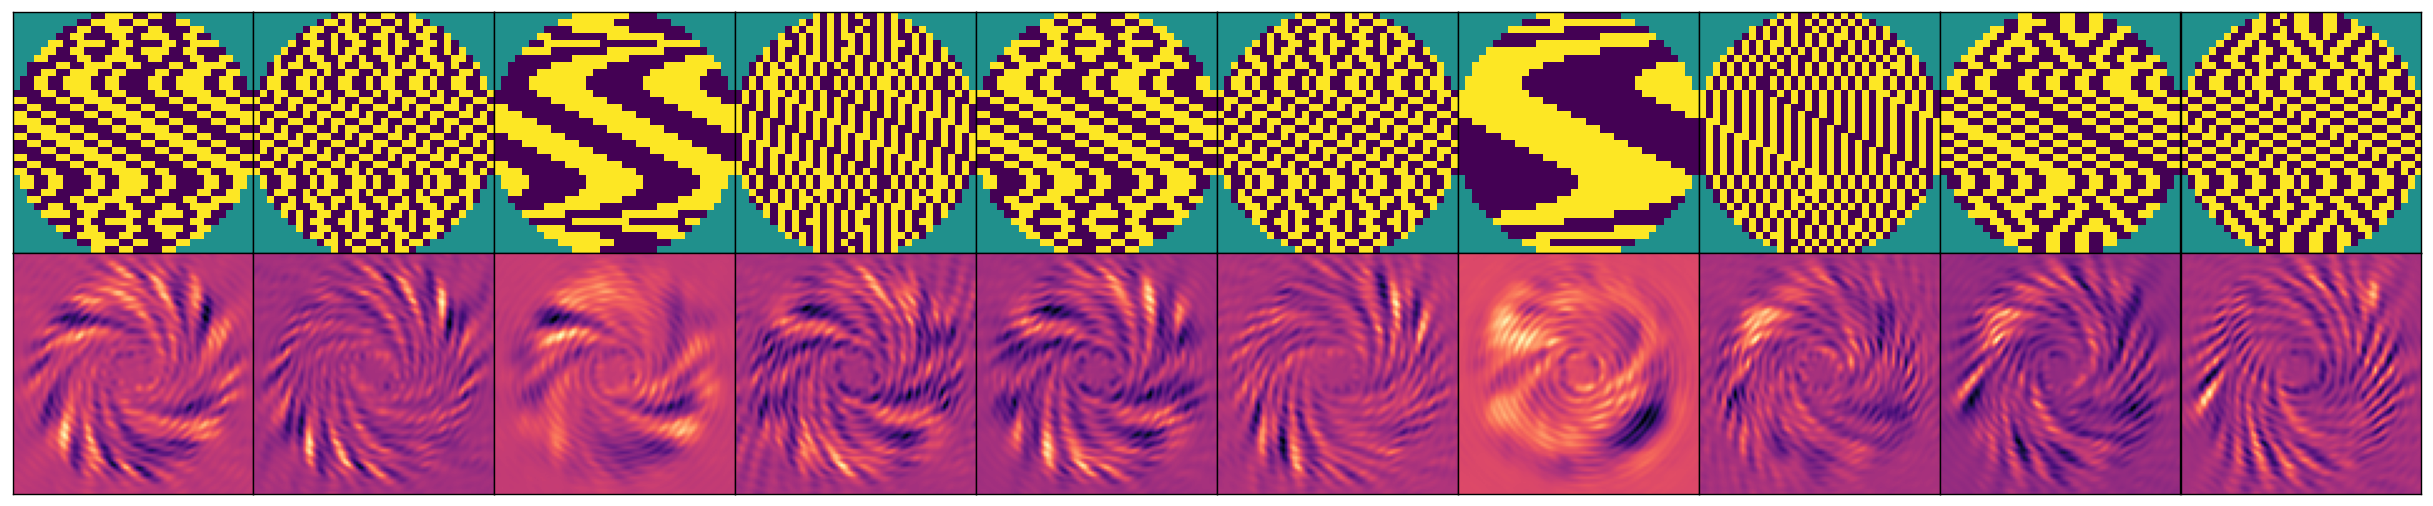

In [60]:
reload(llowfsc)
istart = 10
llowfsc.plot_responses(hadamard_modes[istart:], h_response_cube[istart:])

434699.09248427086


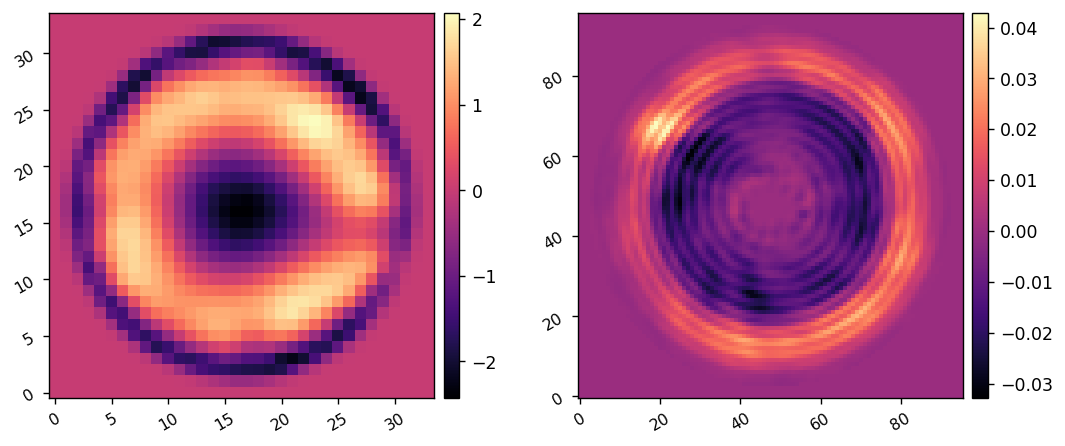

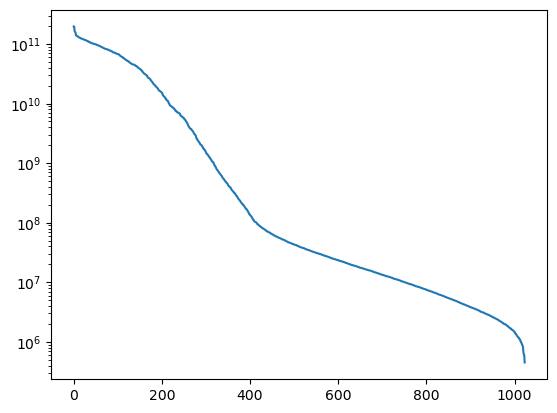

In [61]:
U, s, Vt = xp.linalg.svd(h_rm, full_matrices=False)
svd_dm_modes = Vt.dot(had_modal_matrix)
print(s.max()/s.min())

i = 2
svd_dm_mode = xp.zeros_like(M.dm_total)
svd_dm_mode[M.dm_mask] = svd_dm_modes[i]
wfs_mode = xp.zeros_like(camlo_im_ref)
wfs_mode[llowfsc_mask] = U[:, i]
imshow2(svd_dm_mode, wfs_mode)
plt.semilogy(ensure_np_array(s))


29.0888208681574 nm
0.0005
0.002


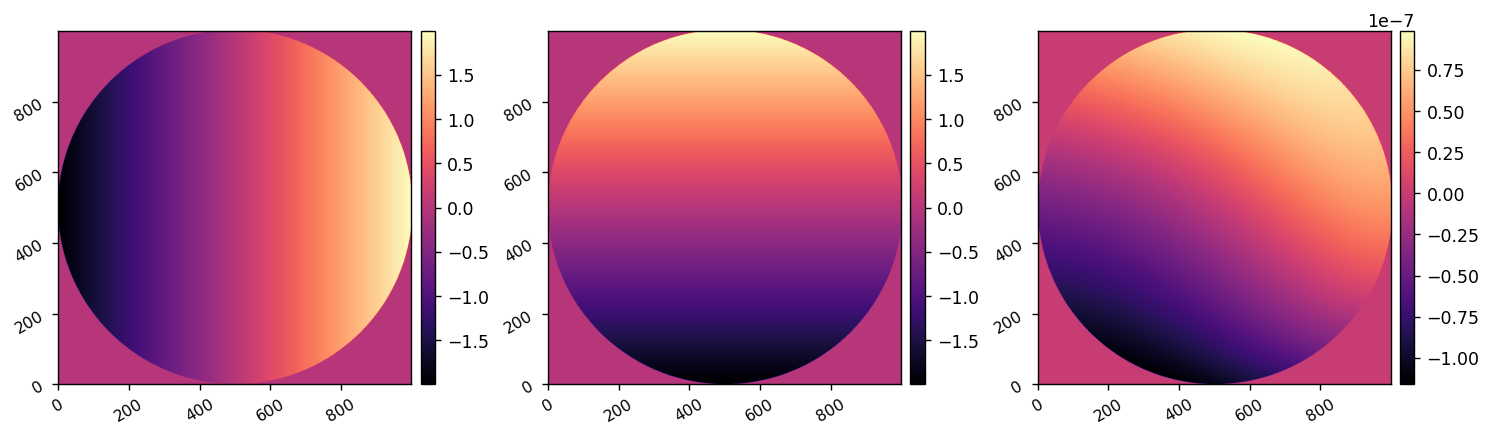

In [62]:
from scoob_llowfsc import psds
import copy
reload(psds)

total_pupil_diam = 2.4*u.m
dm_beam_diam = 9.1*u.mm
jitter = 10*u.mas 

fmax = 1000*u.Hz
tmax = 5*u.s
# tmax = 1*u.hour
# tmax = 5*u.hour

mag = (total_pupil_diam / dm_beam_diam).decompose().value
tt_pv_to_rms = 1/4
tt_at_pupil_pv = np.tan(mag*jitter).value * dm_beam_diam
tt_at_pupil_rms = tt_at_pupil_pv * tt_pv_to_rms
print(tt_at_pupil_rms.to(u.nm))

wfe_modes_rms = np.array(2*[tt_at_pupil_rms.to_value(u.m)] + 8*[2.5e-9])
# wfe_modes_rms = np.array(2*[30e-9] + 3*[5e-9] + 5*[2.5e-9])
# knee_freqs = np.array([0.05]*2 + [0.005]*8) * u.Hz
knee_freqs = np.array([1]*2 + [0.01]*8) * u.Hz
slope = 4

N_wfe_modes = len(wfe_modes_rms)
wfe_modes = utils.create_zernike_modes(M.APERTURE, nmodes=N_wfe_modes, remove_modes=1)

freqs, times = psds.generate_freqs(Nf=2**22+1, f_max=fmax)
delT = times[1] - times[0]

wfe_psds = xp.zeros((N_wfe_modes, len(freqs)))
wfe_time_series = xp.zeros((N_wfe_modes, len(times)))
seeds = 123 + np.linspace(0, N_wfe_modes-1, N_wfe_modes).astype(int)
for i in range(N_wfe_modes):
    f_knee = knee_freqs[i]
    psd = psds.kneePSD(freqs, 1, f_knee.to_value(u.Hz), slope)
    wfe_psds[i] = copy.copy(psd)
    coeff = psds.generate_time_series(psd, fmax, rms=1, seed=seeds[i])
    sign = 1 if xp.random.randn(1)>0 else -1
    wfe_time_series[i] = wfe_modes_rms[i] * sign * xp.array(coeff)


wfe_time_series = wfe_time_series[:, times<tmax.to_value(u.s)]
times = times[times<tmax.to_value(u.s)]
delT = times[1] - times[0]
print(delT)

wfe_time_series = wfe_time_series[:, ::4]
times = times[::4]
delT = times[1] - times[0]
print(delT)

lo_wfe = xp.sum( wfe_time_series[:, 500, None, None] * wfe_modes, axis=0)
imshow3(wfe_modes[0], wfe_modes[1], lo_wfe)

/home/kianmilani/Projects/scoob-llowfsc/scoob_llowfsc/psds.py:149: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax[0].set_xlim(psd_xlims)


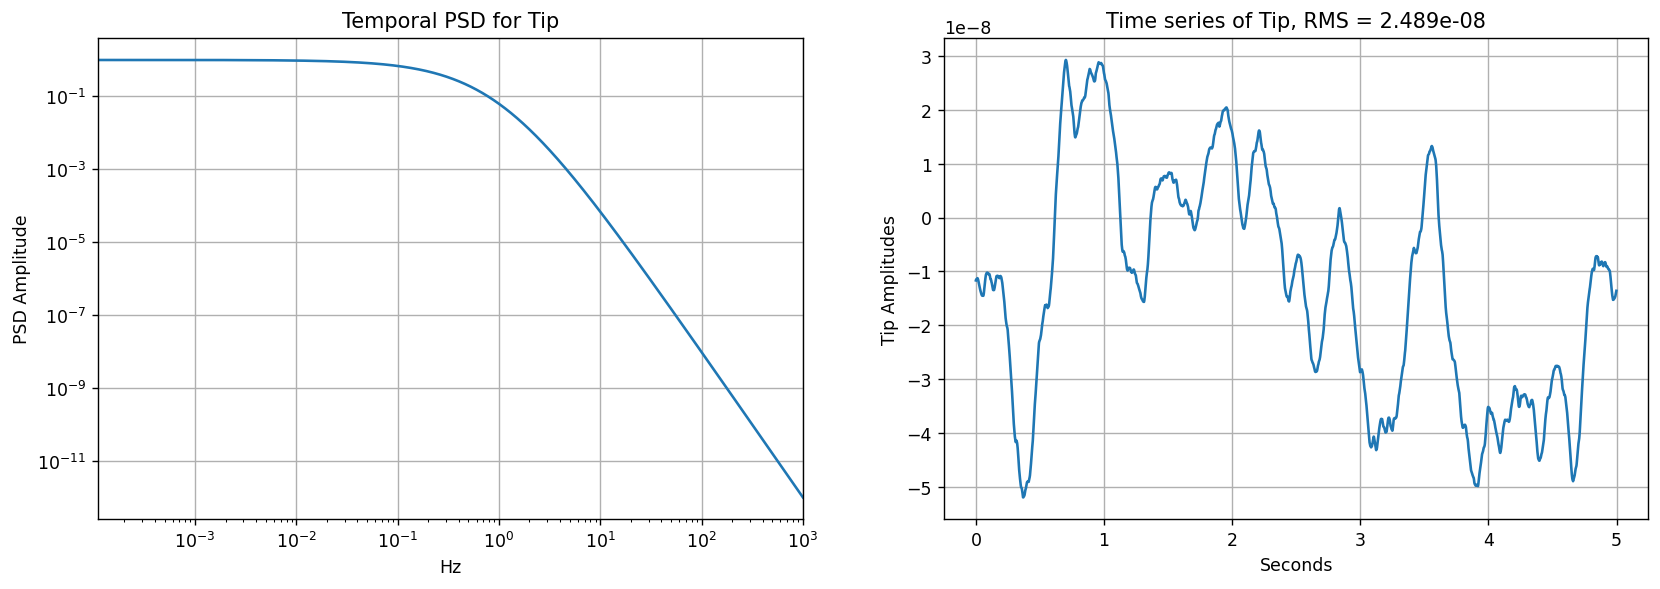

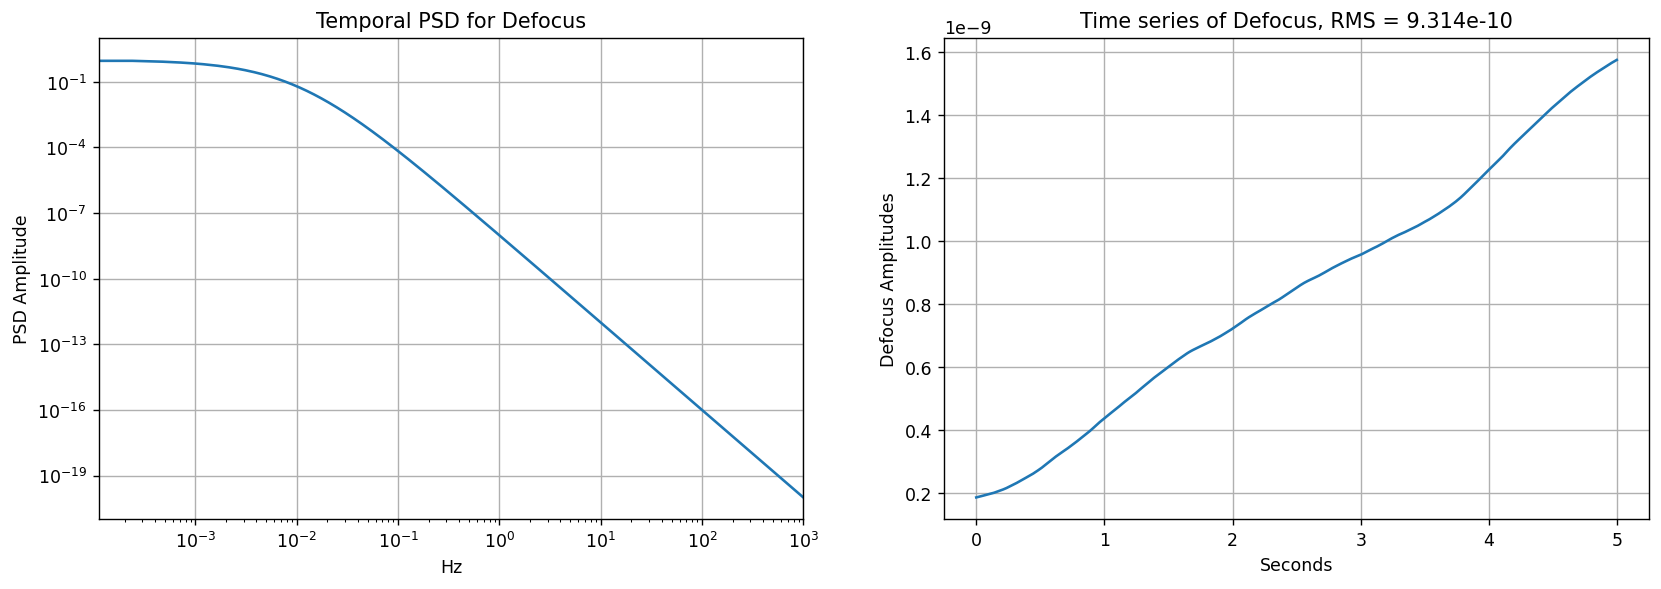

In [63]:
reload(psds)
i = 0
psd = wfe_psds[i]
coeff = wfe_time_series[i]

psds.plot_psd_and_time_series(
    freqs, psd,
    times, coeff,
    psd_name='for Tip',
    coeff_name='Tip',
    psd_xlims=[freqs.min(), 1000],
    # coeff_xlims=[0, 3600],
    # coeff_xticks=np.arange(0,3600+1,600),
    figsize=(16,5),
)

i = 2
psd = wfe_psds[i]
coeff = wfe_time_series[i]

psds.plot_psd_and_time_series(
    freqs, psd,
    times, coeff,
    psd_name='for Defocus',
    coeff_name='Defocus',
    psd_xlims=[freqs.min(), 1000],
    # coeff_xlims=[0, 3600],
    # coeff_xticks=np.arange(0,3600+1,600),
    figsize=(16,5),
)

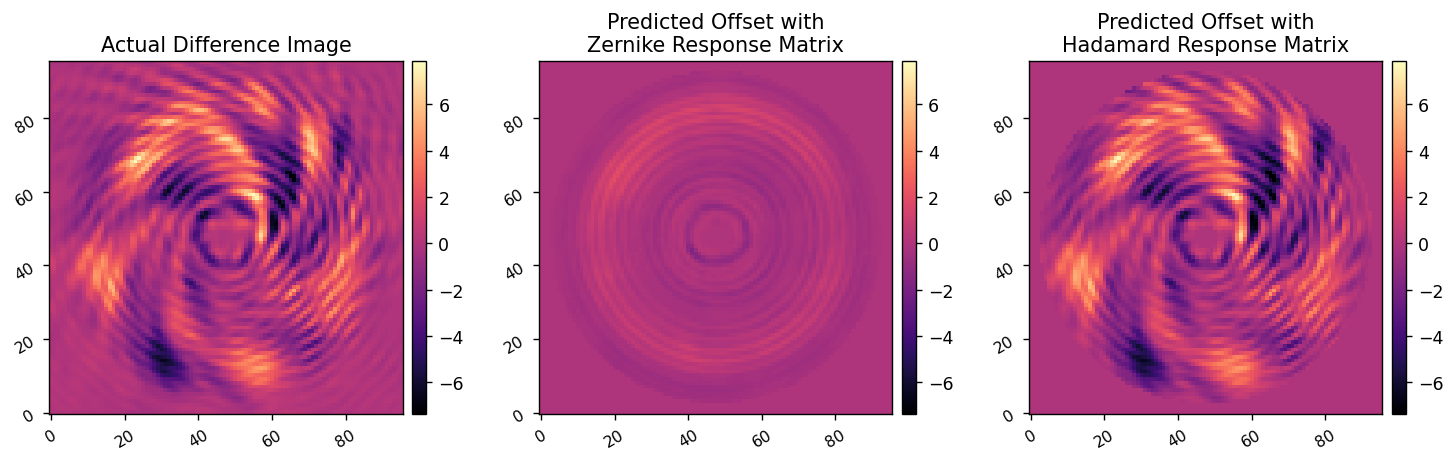

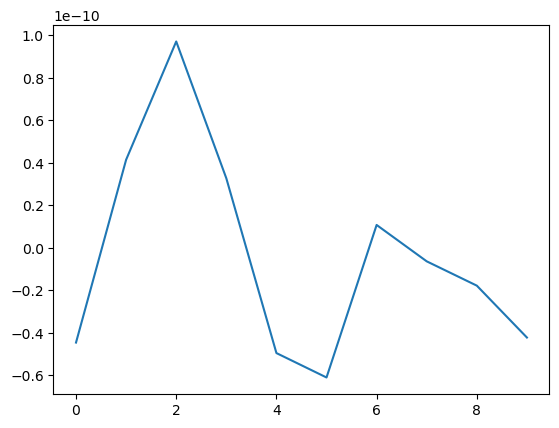

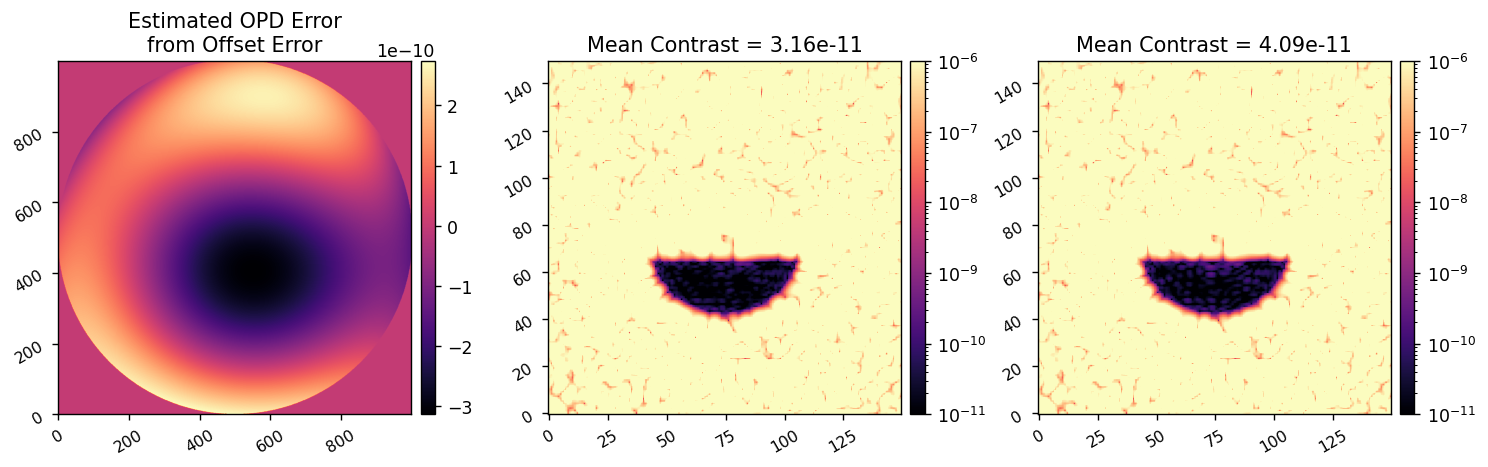

In [74]:
M.PREFPM_AMP = wfe_data['PREFPM_AMP']
M.PREFPM_OPD = wfe_data['PREFPM_OPD']
M.reset_dm()
M.add_dm(dh_command, 3)
ref_offset_truth = M.snap_camlo() - camlo_im_ref

ref_offset_zer = xp.zeros_like(camlo_im_ref)
ref_offset_zer[llowfsc_mask] = z_rm.dot( zer_modal_matrix.dot( dh_command[M.dm_mask] ) / 952 )

ref_offset_had = xp.zeros_like(camlo_im_ref)
ref_offset_had[llowfsc_mask] = h_rm.dot( had_modal_matrix.dot( dh_command[M.dm_mask] ) / 1024)

imshow3(
    ref_offset_truth, ref_offset_zer, ref_offset_had,
    'Actual Difference Image', 
    'Predicted Offset with\nZernike Response Matrix', 
    'Predicted Offset with\nHadamard Response Matrix', 
    vmin1=xp.min(ref_offset_truth), vmax1=xp.max(ref_offset_truth), 
    vmin2=xp.min(ref_offset_truth), vmax2=xp.max(ref_offset_truth),
    vmin3=xp.min(ref_offset_truth), vmax3=xp.max(ref_offset_truth),
    # cmap1='bwr', cmap2='bwr', cmap3='bwr',
)

had_error = llowfsc_mask*ref_offset_truth - ref_offset_had
control_matrix = utils.TikhonovInverse(z_rm, 0)
coeff = control_matrix.dot(had_error[llowfsc_mask])
plt.plot(coeff.get())
plt.show()
lo_opd = xp.sum( coeff[:, None, None] * wfe_modes, axis=0)

M.PREFPM_OPD = wfe_data['PREFPM_OPD'] + lo_opd
camsci_im_dh = M.snap_camsci()
contrast = xp.mean(camsci_im_dh[dark_hole_mask])
imshow3(
    lo_opd, camsci_im_dh0, camsci_im_dh, 
    'Estimated OPD Error\nfrom Offset Error', 
    f'Mean Contrast = {contrast_dh0:.2e}',
    f'Mean Contrast = {contrast:.2e}',
    lognorm2=1, vmin2=1e-11, vmax2=1e-6,
    lognorm3=1, vmin3=1e-11, vmax3=1e-6,
)

# imshow3(
#     del_ref_im_0, del_ref_im_had, double_diff, 
#     'Actual Difference Image', 'Predicted with Hadamard Response Matrix', 'Error', 
#     vmin1=xp.min(del_ref_im_0), vmax1=xp.max(del_ref_im_0), 
#     vmin2=xp.min(del_ref_im_0), vmax2=xp.max(del_ref_im_0),
# # vmin3=xp.min(del_ref_im_0), vmax3=xp.max(del_ref_im_0), 
# )

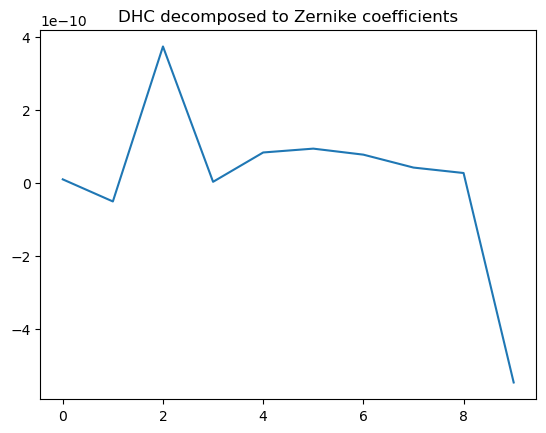

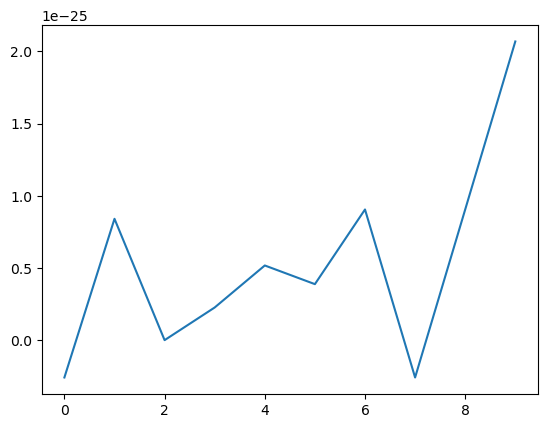

In [115]:
reload(utils)
zer_coeff = utils.lstsq(zernike_modes, dh_command)
zer_coeff_2 = zer_modal_matrix.dot(dh_command[M.dm_mask]) / 952
plt.plot(zer_coeff.get())
plt.title('DHC decomposed to Zernike coefficients')
plt.show()
plt.plot(zer_coeff.get() - zer_coeff_2.get())
plt.show()

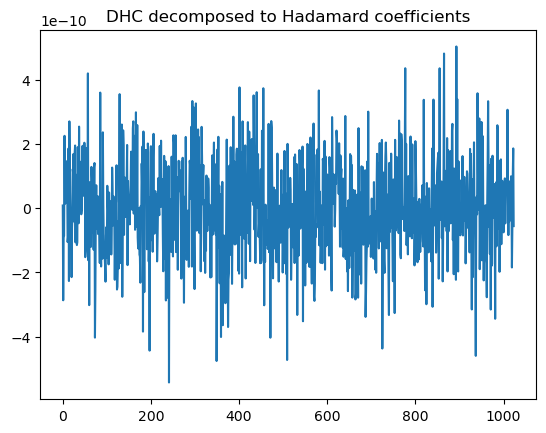

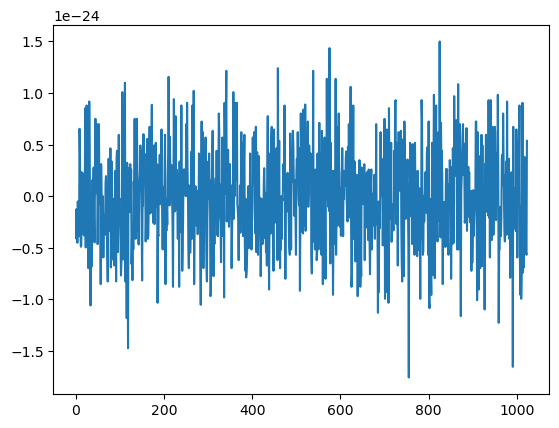

In [78]:
reload(utils)
had_coeff = utils.lstsq(hadamard_modes, dh_command)
had_coeff_2 = had_modal_matrix.dot(dh_command[M.dm_mask]) / 1024
plt.plot(had_coeff.get())
plt.title('DHC decomposed to Hadamard coefficients')
plt.show()
plt.plot(had_coeff.get() - had_coeff_2.get())
plt.show()

In [118]:
wfe_time_series.shape

(10, 2500)

In [119]:
reload(llowfsc)

M.reset_dm()
M.set_dm(dh_command, 3)

ref_offset_had = xp.zeros_like(camlo_im_ref)
ref_offset_had[llowfsc_mask] = h_rm.dot( had_modal_matrix.dot( dh_command[M.dm_mask] ) / 1024)

gains = xp.array(2*[0.5] + 8*[0.1])

llowfsc_dict = llowfsc.run(
    M, 
    wfe_data['PREFPM_AMP'], wfe_data['PREFPM_OPD'],
    camlo_im_ref + ref_offset_had,
    llowfsc_mask, 
    control_matrix, 
    # wfe_time_series[:, :10],
    # wfe_time_series[:, :200],
    wfe_time_series, 
    wfe_modes, 
    zernike_modes,
    channel=2,
    gain=gains,  
    leakage=0.0,
    # plot=True, 
    # sleep=1,
    # plot_all=True,
)


Starting LLOWFSC control-loop simulation


6.042925772526325e-10


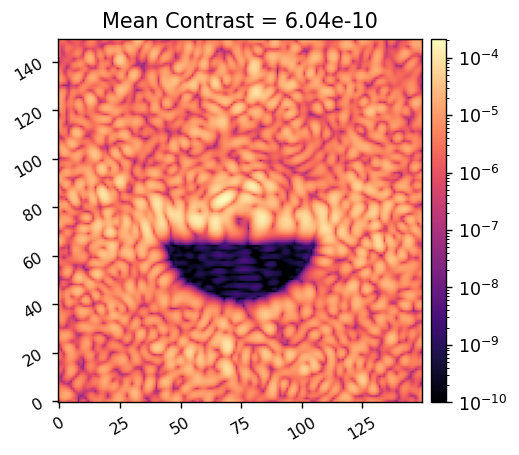

In [120]:
mean_camsci_im = xp.mean(llowfsc_dict['coro_ims'][50:], axis=0)
mean_contrast = xp.mean( mean_camsci_im[dark_hole_mask])
print(mean_contrast)

imshow1(mean_camsci_im, f'Mean Contrast = {mean_contrast:.2e}', lognorm=1, vmin=1e-10)

6.371105070236326e-10


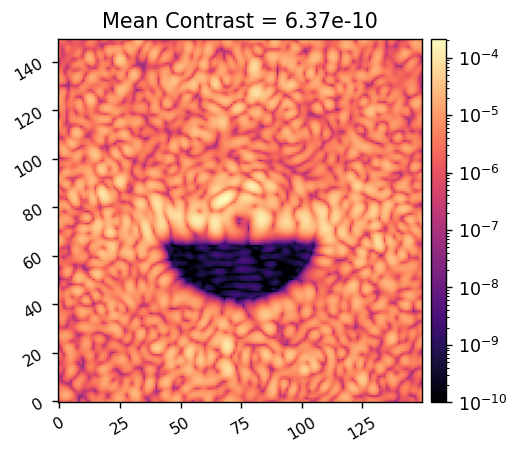

In [117]:
mean_camsci_im = xp.mean(llowfsc_dict['coro_ims'][50:], axis=0)
mean_contrast = xp.mean( mean_camsci_im[dark_hole_mask])
print(mean_contrast)

imshow1(mean_camsci_im, f'Mean Contrast = {mean_contrast:.2e}', lognorm=1, vmin=1e-10)

6.14129035474616e-10


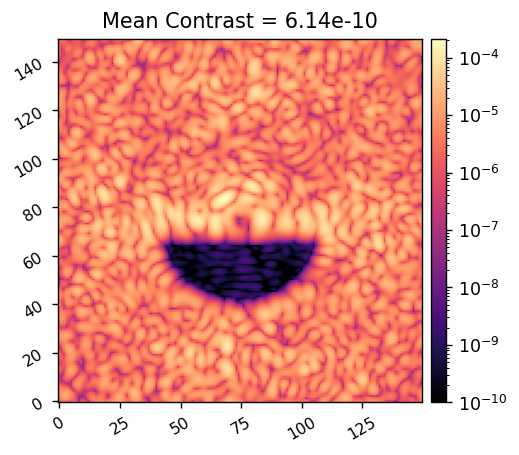

In [99]:
mean_camsci_im = xp.mean(llowfsc_dict['coro_ims'][50:], axis=0)
mean_contrast = xp.mean( mean_camsci_im[dark_hole_mask])
print(mean_contrast)

imshow1(mean_camsci_im, f'Mean Contrast = {mean_contrast:.2e}', lognorm=1, vmin=1e-10)